# Trajectory Visualizations

In [1]:
from visualize_trajectory_projections import *

num_plot_trajectories = 10


In [2]:
def plot_trajectory(max_newton, push_vel=0, date='2025-09-23_10-21-13', ylimit=True, ep_length=20, num_trajectories=10):
    
    data_name = 'g1_balance_{}_newton_{}_traj_{}s'.format(max_newton, num_trajectories, ep_length)
    if push_vel > 0:
        data_name += '_push_vel_{}'.format(push_vel)
    data_name += '_' + date
    cur_dir = os.getcwd()
    load_path = os.path.join(cur_dir, 'datasets', '{}.npz'.format(data_name))
    loaded_data = TrajectoryDataset(load_path)
    trajectories = DataLoader(
        loaded_data,
        batch_size=1,
        shuffle=True,
        num_workers=0,
    )
    visualize_trajectories(trajectories, num_plot_trajectories, filename=None, ylimit=ylimit)

## No Perturbations

0 N Forces and 0 Nm Torques.

Notice the initial high position/velocity errors. This is because the robot starts a few centimeters off the ground and initially drops.

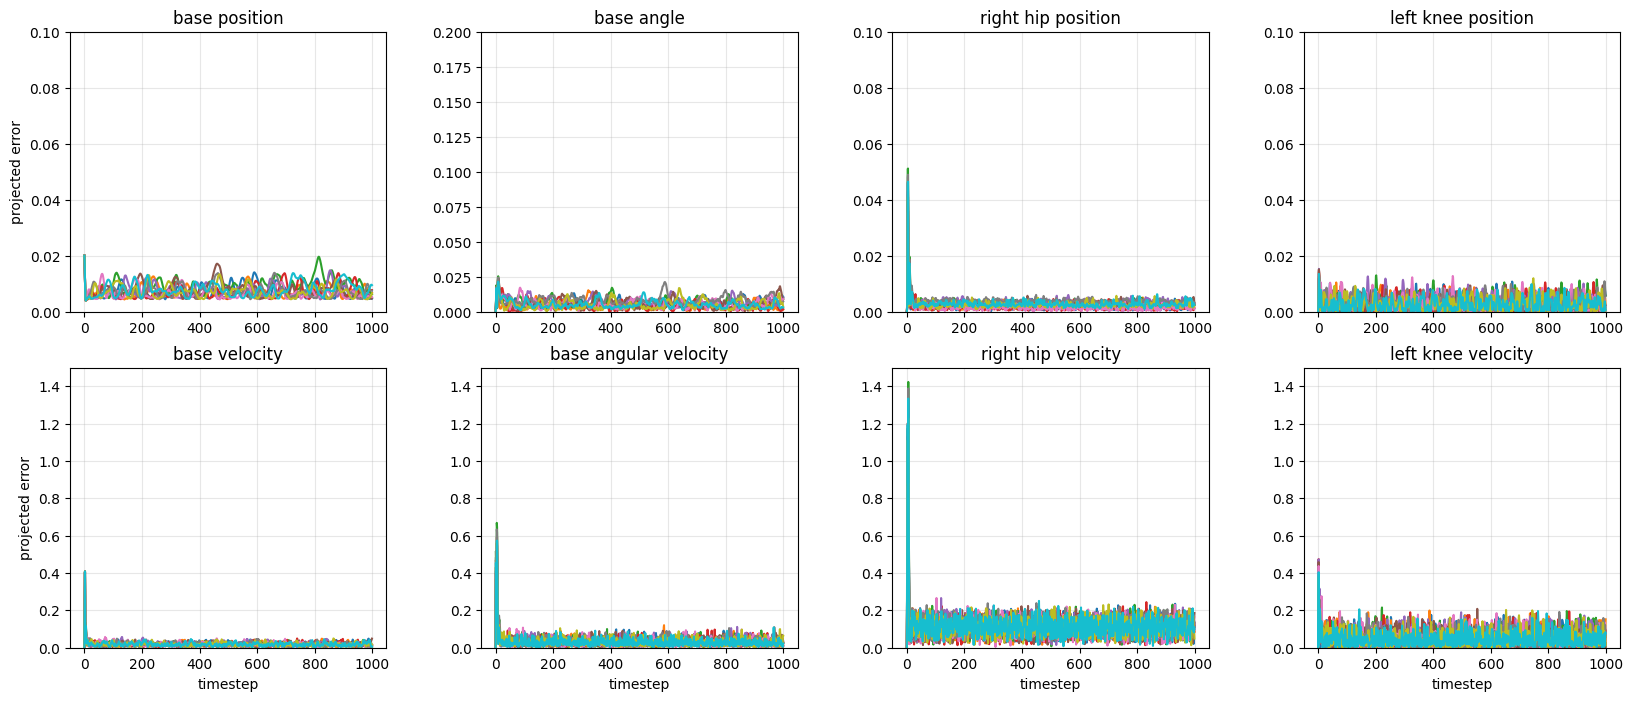

In [3]:
max_newton = 0
plot_trajectory(max_newton)

## Large Perturbations (out of training distribution)

Uniform(-20, 20) forces and torques at t=0.

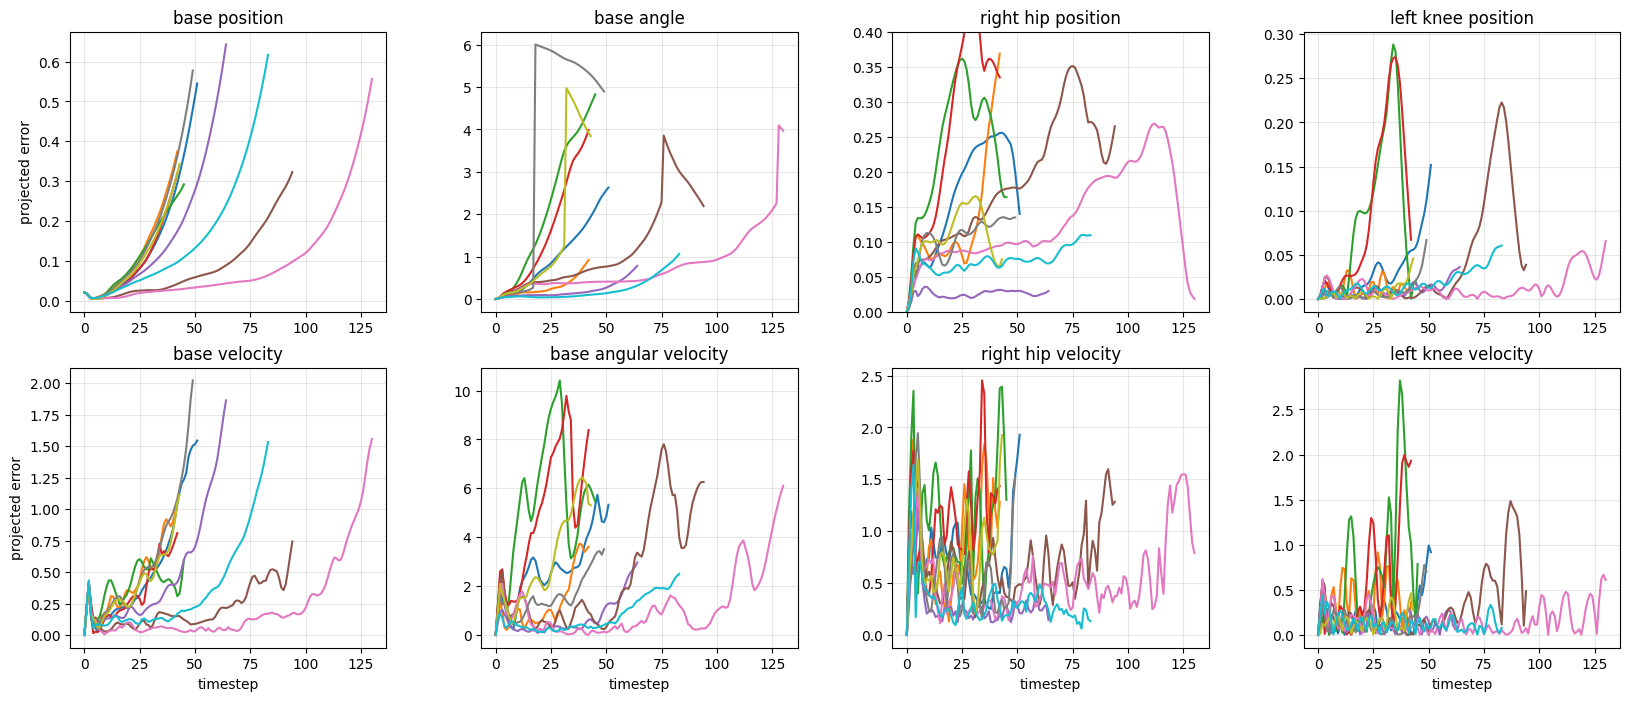

In [4]:
max_newton = 20
plot_trajectory(max_newton, ylimit=False)

# Normal Perturbations

Uniform(-8, 8) forces and torques at t=0.

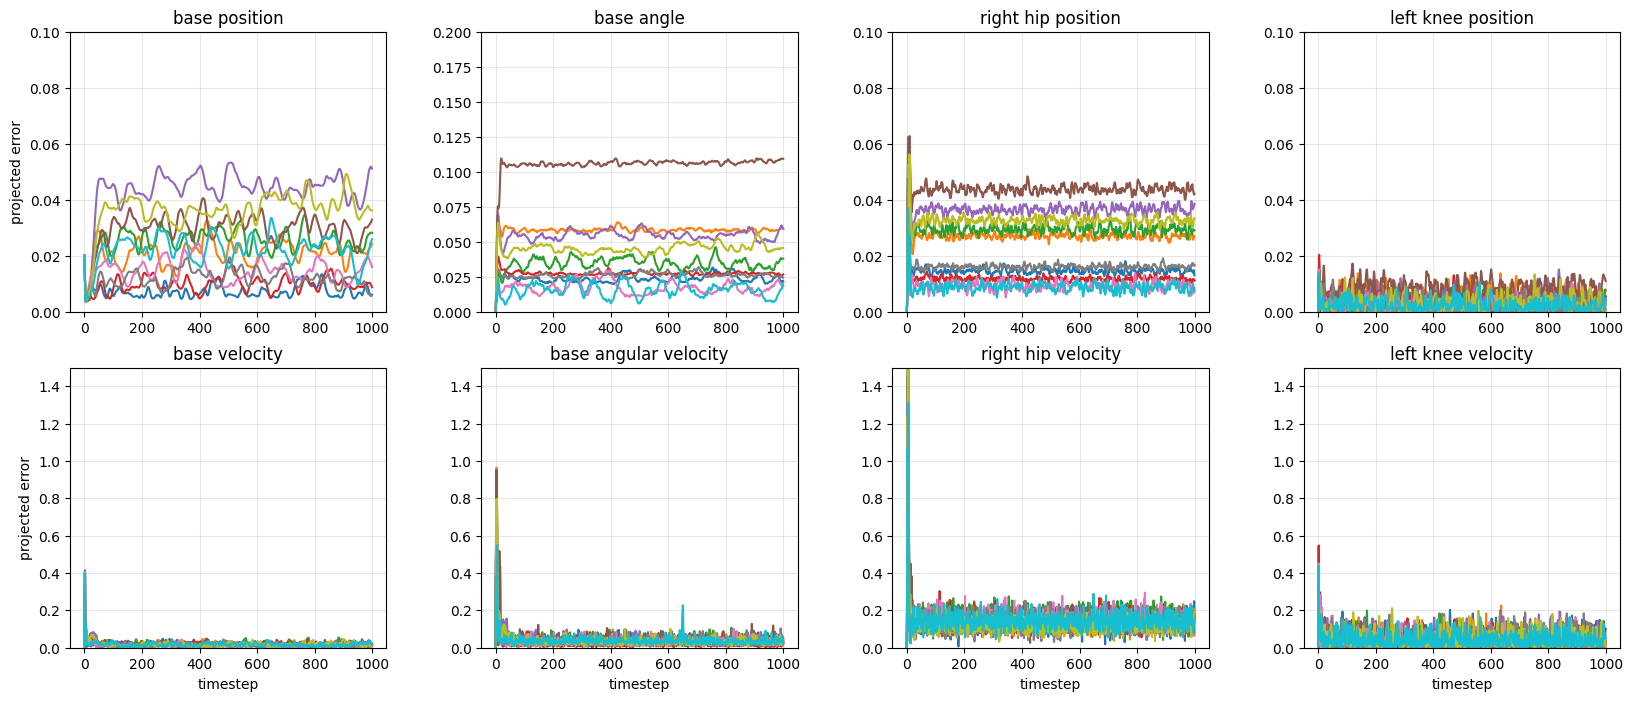

In [5]:
max_newton = 8
plot_trajectory(max_newton)

## Push by Setting Velocity

Velocity = 0.2 at t=0

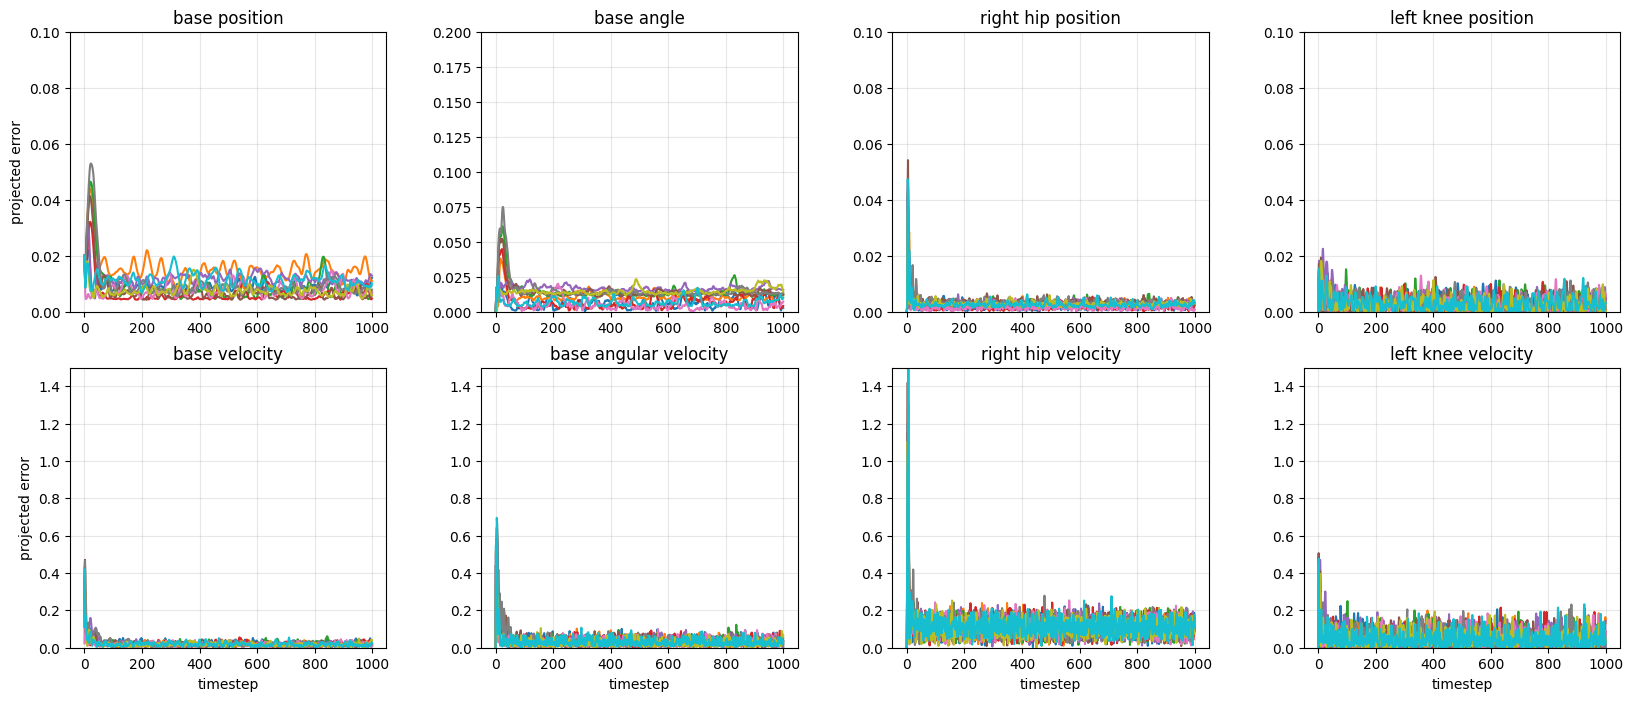

In [6]:
max_newton = 0
push_vel=0.2
plot_trajectory(max_newton, push_vel=push_vel)

Velocity = 0.5 at t=0

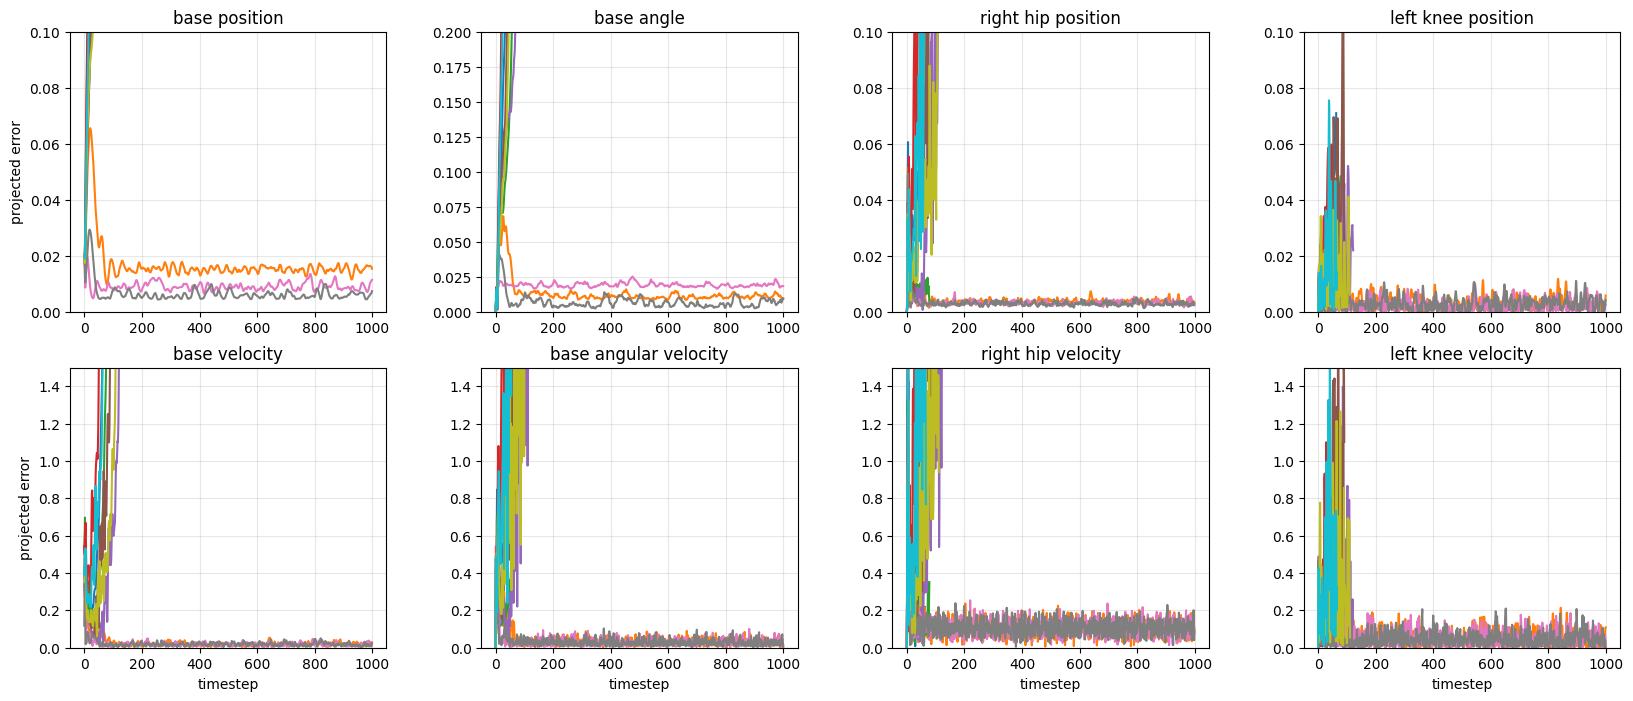

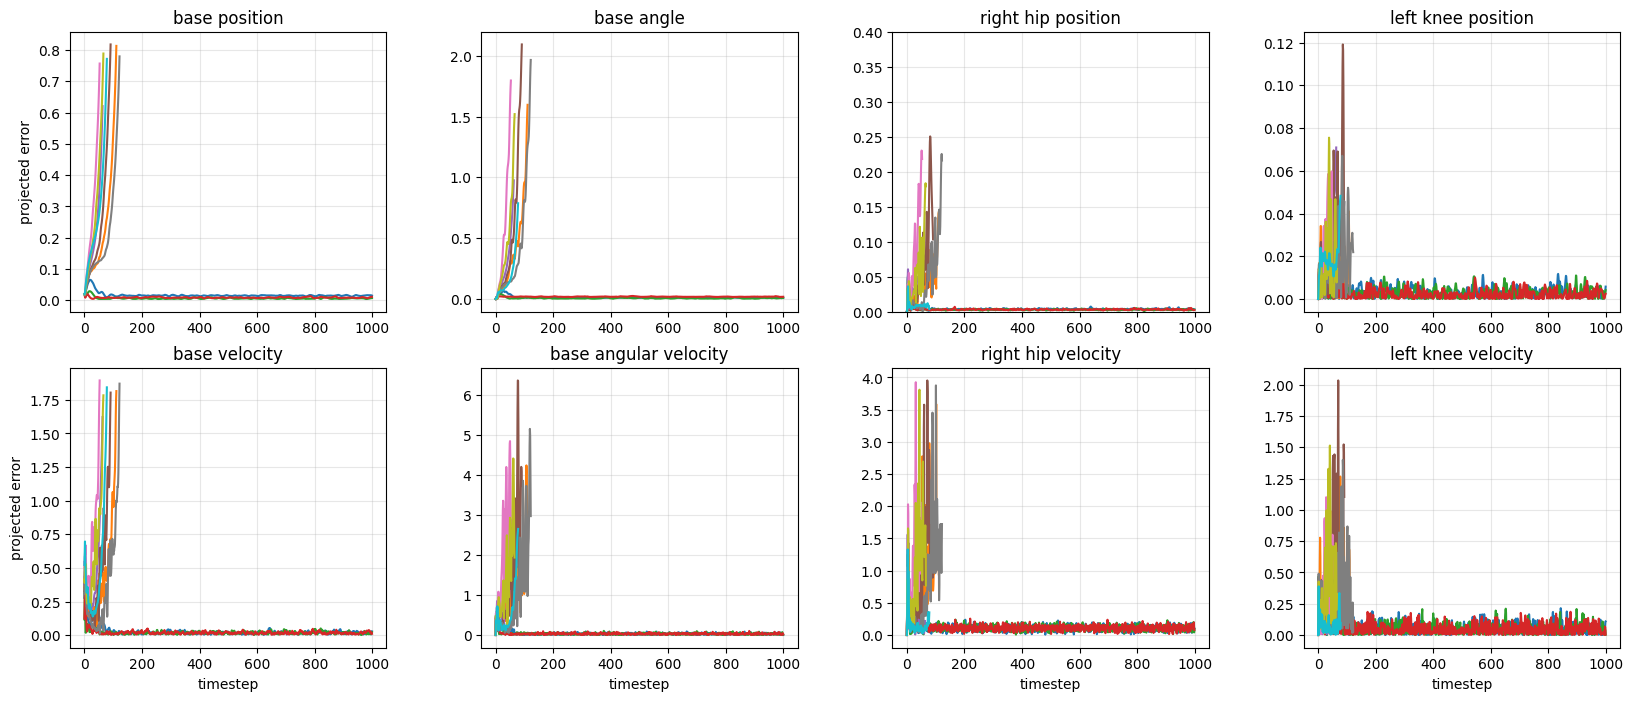

In [7]:
max_newton = 0
push_vel=0.5
plot_trajectory(max_newton, push_vel=push_vel, ylimit=True)
plot_trajectory(max_newton, push_vel=push_vel, ylimit=False)

Velocity = 0.3 at t=5, 10s, 15s.

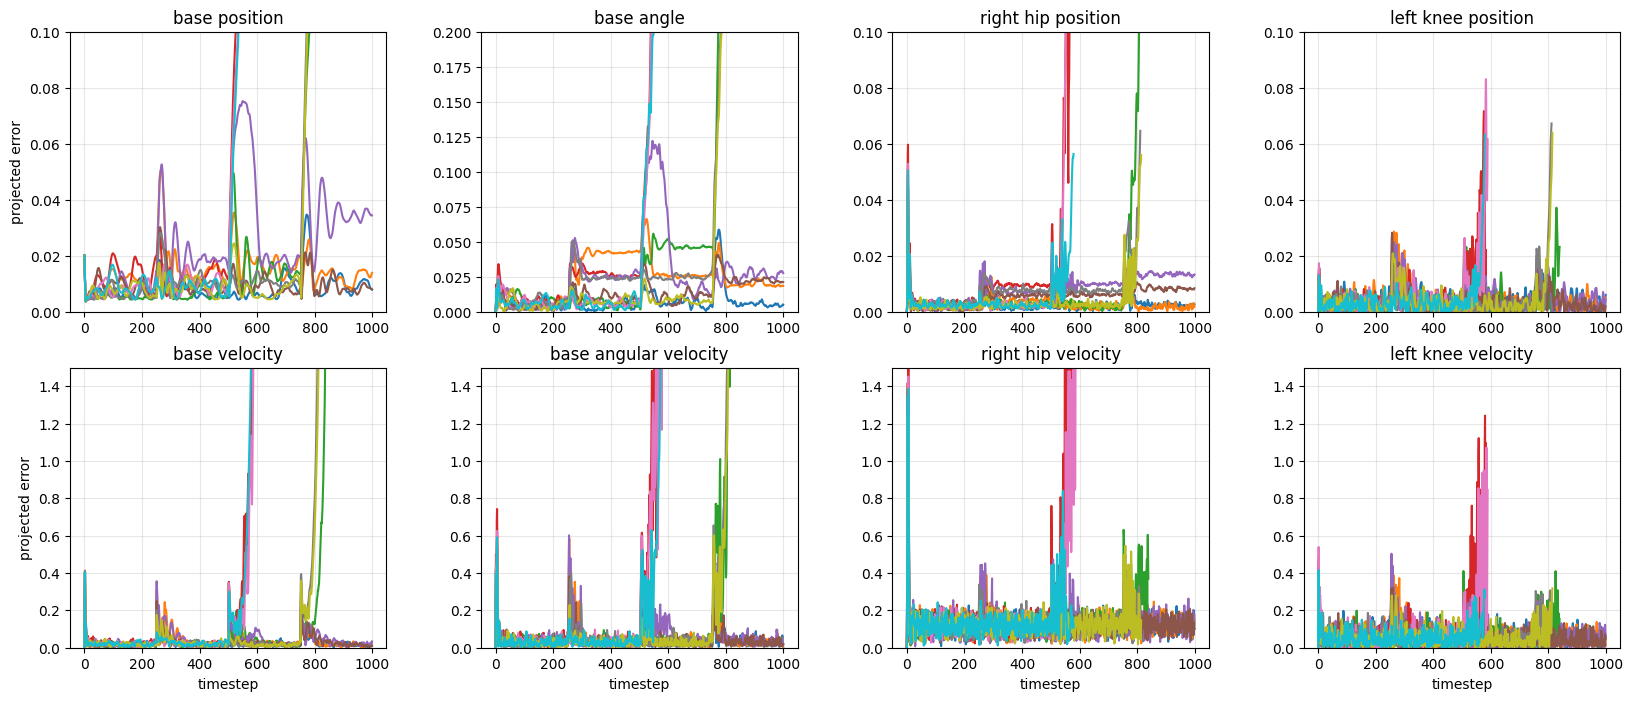

In [8]:
max_newton = 0
push_vel=0.3
plot_trajectory(max_newton, push_vel=push_vel)

## Force perturbations + Impulse

Small random force and torque at beginning of episode.
"Push" velocity every 5 seconds (once at 5 seconds and once at 10 seconds).
15 seconds total episode length.

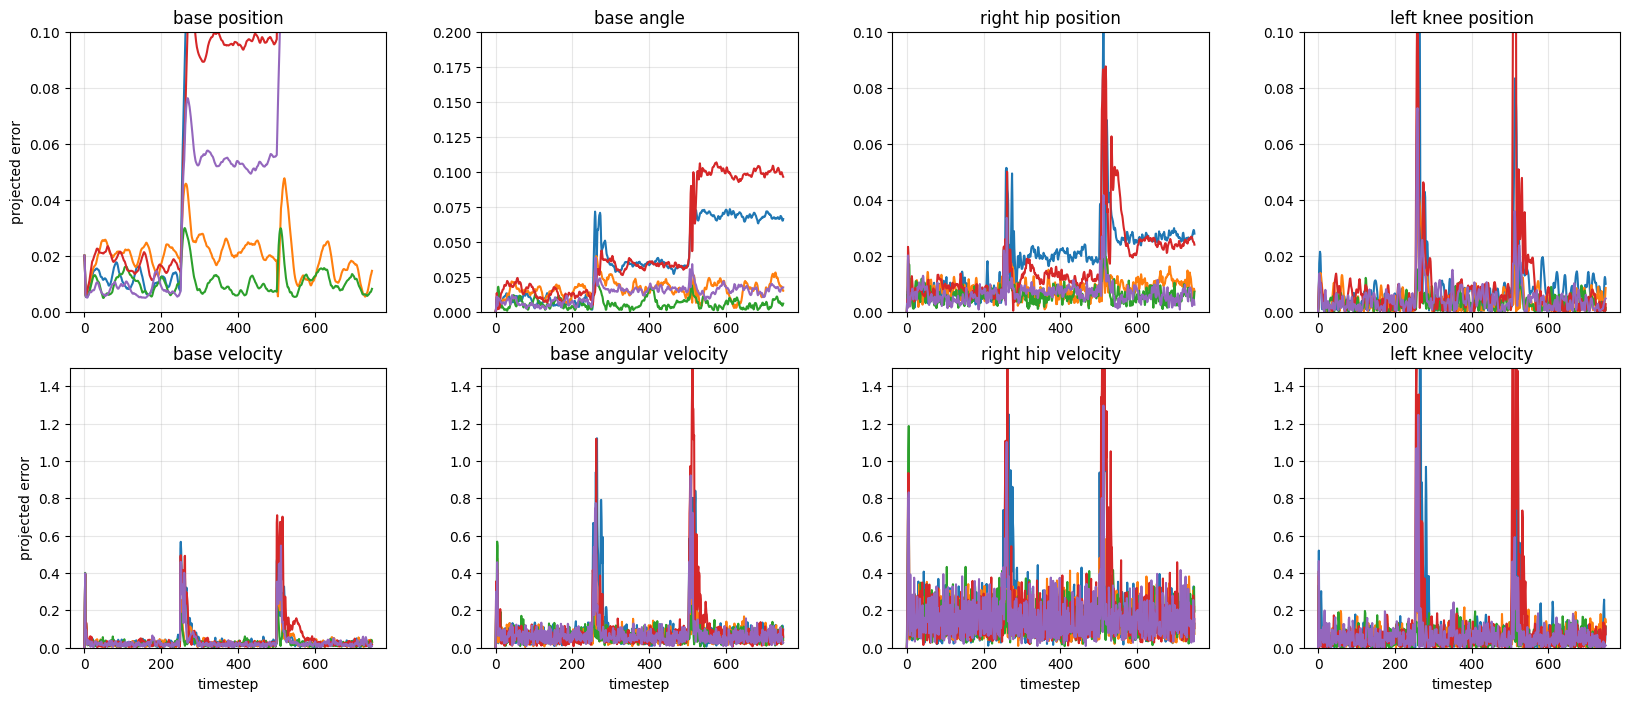

In [9]:
max_newton = 3
push_vel=0.5
date = '2025-09-30_15-47-55'
num_plot_trajectories = 5
plot_trajectory(max_newton, push_vel=push_vel, date=date, ep_length=15, num_trajectories=100)

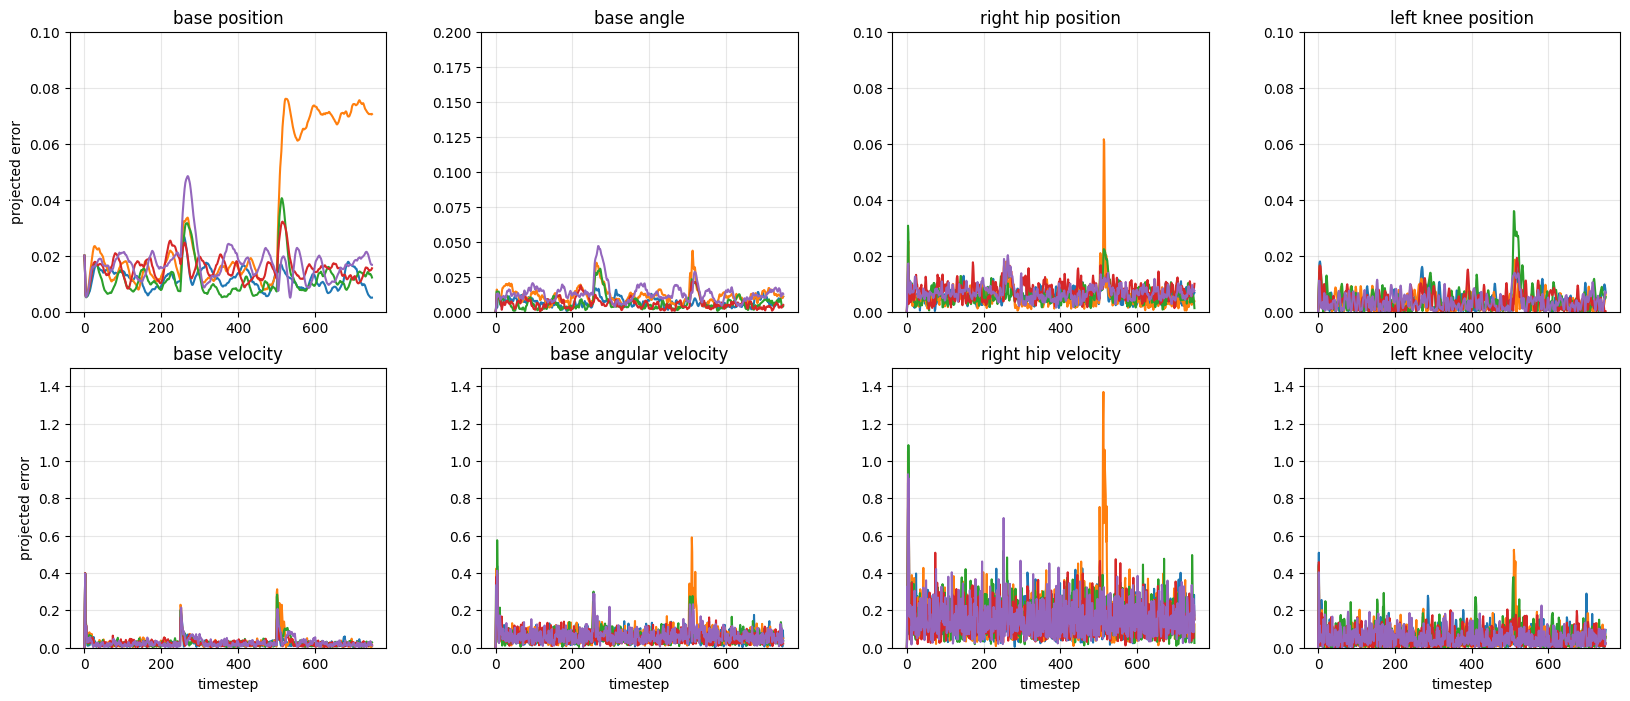

In [10]:
max_newton = 2
push_vel=0.25
date = '2025-09-30_15-47-55'
num_plot_trajectories = 5
plot_trajectory(max_newton, push_vel=push_vel, date=date, ep_length=15, num_trajectories=10)